# Earth2Studio: AI Weather Forecasting

This notebook demonstrates NVIDIA Earth2Studio for:
1. **2m Temperature** forecast (FCN)
2. **10m Wind Speed & MSLP** forecasts (SFNO)
3. **Hurricane Florence track comparison** (SFNO vs FCN vs ERA5 reanalysis)
4. **14-day extended range forecast** — Aurora Z500 animated GIF (Jan 2025 polar vortex)

### Prerequisites
- Python 3.12 with the `earth2` kernel
- `uv sync` (resolves all Earth2Studio extras)
- NVIDIA GPU with CUDA

---
## Imports & Config

In [17]:
import io
import os
from pathlib import Path
from datetime import datetime, timedelta

import imageio
import numpy as np
import torch
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from IPython.display import Image as IPImage
from tqdm import tqdm

import earth2studio.run as run
from earth2studio.models.px import Aurora, FCN, SFNO
from earth2studio.models.dx import TCTrackerWuDuan
from earth2studio.data import GFS, ARCO, WB2ERA5, NCAR_ERA5, fetch_data, prep_data_array
from earth2studio.io import ZarrBackend
from earth2studio.utils.time import to_time_array
from earth2studio.utils.coords import map_coords

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PROJECT_DIR = Path("/home/jovyan/Earth2")
os.chdir(PROJECT_DIR)

os.makedirs(PROJECT_DIR / "aifs_outputs", exist_ok=True)
os.makedirs(PROJECT_DIR / "aurora_outputs", exist_ok=True)

print(f"Device: {DEVICE}")

Device: cuda

## 2m Air Temperature Forecast

In [18]:
model = FCN.load_model(FCN.load_default_package())
data = GFS()

t2m_path = PROJECT_DIR/"t2m_outputs/fcn_gfs_forecast.zarr"
backend = ZarrBackend(str(t2m_path), backend_kwargs={"overwrite": True})

backend = run.deterministic(["2026-01-08"], 10, model, data, backend)
print(backend.root.tree())

del model
torch.cuda.empty_cache()

2026-08-08 13:11:14.274 | INFO     | earth2studio.run:deterministic:87 - Running simple workflow!
2026-08-08 13:11:14.274 | INFO     | earth2studio.run:deterministic:94 - Inference device: cuda

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

2026-08-08 13:11:14.394 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 413181533-966042
2026-08-08 13:11:14.396 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 329645190-898530
2026-08-08 13:11:14.401 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 420824303-1176329
2026-08-08 13:11:14.428 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 394176955-956678
2026-08-08 13:11:14.433 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 414147575-944928
2026-08-08 13:11:14.460 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

2026-08-08 13:11:14.465 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 458275515-977912
2026-08-08 13:11:14.491 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 398557080-950478
2026-08-08 13:11:14.496 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 259520800-914487
2026-08-08 13:11:14.521 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 459253427-968705
2026-08-08 13:11:14.527 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 409106778-875921
2026-08-08 13:11:14.553 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS 

...

2026-08-08 13:11:14.691 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 253820556-806142
2026-08-08 13:11:14.707 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 200278084-732664
2026-08-08 13:11:14.724 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 337303134-947326
2026-08-08 13:11:14.729 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 331385039-869528
2026-08-08 13:11:14.755 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 336364985-938149
2026-08-08 13:11:14.770 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS 

Fetching GFS data: 100%|██████████| 26/26 [00:00<00:00, 54.99it/s]

2026-08-08 13:11:14.904 | SUCCESS  | earth2studio.run:deterministic:156 - Fetched data from GFS
2026-08-08 13:11:14.905 | INFO     | earth2studio.run:deterministic:164 - Inference starting!

Running inference: 100%|██████████| 11/11 [00:10<00:00,  1.05it/s]

2026-08-08 13:11:25.414 | SUCCESS  | earth2studio.run:deterministic:191 - 
Inference complete
/
├── lat (720,) float64
├── lead_time (11,) timedelta64[h]
├── lon (1440,) float64
├── msl (1, 11, 720, 1440) float32
├── r500 (1, 11, 720, 1440) float32
├── r850 (1, 11, 720, 1440) float32
├── sp (1, 11, 720, 1440) float32
├── t250 (1, 11, 720, 1440) float32
├── t2m (1, 11, 720, 1440) float32
├── t500 (1, 11, 720, 1440) float32
├── t850 (1, 11, 720, 1440) float32
├── tcwv (1, 11, 720, 1440) float32
├── time (1,) datetime64[ns]
├── u1000 (1, 11, 720, 1440) float32
├── u100m (1, 11, 720, 1440) float32
├── u10m (1, 11, 720, 1440) float32
├── u250 (1, 11, 720, 1440) float32
├── u500 (1, 11, 720, 1440) float32
├── u850 (1, 11, 720, 1440) float32
├── v1000 (1, 11, 720, 1440) float32
├── v100m (1, 11, 720, 1440) float32
├── v10m (1, 11, 720, 1440) float32
├── v250 (1, 11, 720, 1440) float32
├── v500 (1, 11, 720, 1440) float32
├── v850 (1, 11, 720, 1440) float32
├── z1000 (1, 11, 720, 1440) float32


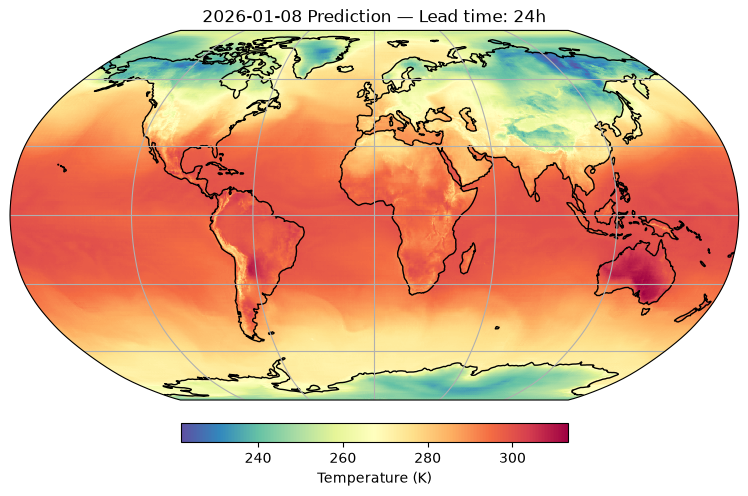

In [3]:
def plot_t2m(zarr_path, variable, step, save_path=None):
    ds = xr.open_zarr(str(zarr_path))
    projection = ccrs.Robinson()

    fig, ax = plt.subplots(subplot_kw={"projection": projection}, figsize=(10, 6))
    im = ax.pcolormesh(
        ds["lon"], ds["lat"], ds[variable][0, step],
        transform=ccrs.PlateCarree(), cmap="Spectral_r",
    )
    plt.colorbar(
            im, 
            ax=ax, 
            orientation="horizontal", 
            pad=0.05, 
            label="Temperature (K)",
            shrink=0.5,  
            aspect=20
)

    ax.set_title(f"2026-01-08 Prediction — Lead time: {6 * step}h")
    ax.coastlines()
    ax.gridlines()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

plot_t2m(t2m_path, "t2m", step=4, save_path=PROJECT_DIR / "t2m_outputs/t2m_prediction.jpg")

---
## 10m Wind Speed & MSLP Forecasts (SFNO)

In [4]:
sfno_model = SFNO.load_model(SFNO.load_default_package())
data = GFS()

sfno_path = PROJECT_DIR / "sfno_outputs/sfno_gfs_forecast.zarr"
sfno_path.parent.mkdir(parents=True, exist_ok=True)
backend = ZarrBackend(str(sfno_path), backend_kwargs={"overwrite": True})

backend = run.deterministic(["2026-01-01"], 10, sfno_model, data, backend)
print(backend.root.tree())

del sfno_model
torch.cuda.empty_cache()

2026-08-08 08:49:45.130 | INFO     | earth2studio.run:deterministic:87 - Running simple workflow!
2026-08-08 08:49:45.130 | INFO     | earth2studio.run:deterministic:94 - Inference device: cuda

Fetching GFS data:   0%|          | 0/73 [00:00<?, ?it/s]

2026-08-08 08:49:45.710 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 416783236-887721
2026-08-08 08:49:45.711 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 305163964-1255574
2026-08-08 08:49:45.726 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 216303384-765135
2026-08-08 08:49:45.727 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 153764980-1113041
2026-08-08 08:49:45.775 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 302363913-859119
2026-08-08 08:49:45.777 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GF

Fetching GFS data:   0%|          | 0/73 [00:00<?, ?it/s]

2026-08-08 08:49:45.920 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 173426573-748944
2026-08-08 08:49:45.937 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 222511451-619141
2026-08-08 08:49:45.953 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 308771191-904973
2026-08-08 08:49:45.967 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 179147390-920513
2026-08-08 08:49:45.984 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 363410338-1239124
2026-08-08 08:49:46.000 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS

...

2026-08-08 08:49:46.565 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 240428987-1260393
2026-08-08 08:49:46.585 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 185037795-749678
2026-08-08 08:49:46.603 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 237568538-833906
2026-08-08 08:49:46.607 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 343808409-947816
2026-08-08 08:49:46.635 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 180067903-910623
2026-08-08 08:49:46.653 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS

Fetching GFS data: 100%|██████████| 73/73 [00:01<00:00, 52.10it/s]

2026-08-08 08:49:46.964 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 190814608-926000
2026-08-08 08:49:46.965 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 221903757-607694
2026-08-08 08:49:46.979 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 157135988-856018
2026-08-08 08:49:46.993 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 283478629-1235647
2026-08-08 08:49:47.006 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 205551634-750666
2026-08-08 08:49:47.021 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS

Running inference: 100%|██████████| 11/11 [00:32<00:00,  2.95s/it]

2026-08-08 08:50:19.762 | SUCCESS  | earth2studio.run:deterministic:191 - 
Inference complete
/
├── lat (721,) float64
├── lead_time (11,) timedelta64[h]
├── lon (1440,) float64
├── msl (1, 11, 721, 1440) float32
├── q100 (1, 11, 721, 1440) float32
├── q1000 (1, 11, 721, 1440) float32
├── q150 (1, 11, 721, 1440) float32
├── q200 (1, 11, 721, 1440) float32
├── q250 (1, 11, 721, 1440) float32
├── q300 (1, 11, 721, 1440) float32
├── q400 (1, 11, 721, 1440) float32
├── q50 (1, 11, 721, 1440) float32
├── q500 (1, 11, 721, 1440) float32
├── q600 (1, 11, 721, 1440) float32
├── q700 (1, 11, 721, 1440) float32
├── q850 (1, 11, 721, 1440) float32
├── q925 (1, 11, 721, 1440) float32
├── sp (1, 11, 721, 1440) float32
├── t100 (1, 11, 721, 1440) float32
├── t1000 (1, 11, 721, 1440) float32
├── t150 (1, 11, 721, 1440) float32
├── t200 (1, 11, 721, 1440) float32
├── t250 (1, 11, 721, 1440) float32
├── t2m (1, 11, 721, 1440) float32
├── t300 (1, 11, 721, 1440) float32
├── t400 (1, 11, 721, 1440) float

In [5]:
def plot_sfno_10m_wind(zarr_path, step, extent=None, save_path=None):
    ds = xr.open_zarr(str(zarr_path))
    ws10 = np.sqrt(ds["u10m"][0, step] ** 2 + ds["v10m"][0, step] ** 2)
    projection = ccrs.Robinson()
    levels = np.arange(0, 40, 2)

    fig, ax = plt.subplots(subplot_kw={"projection": projection}, figsize=(12, 6))
    im = ax.contourf(
        ds["lon"], ds["lat"], ws10, levels,
        transform=ccrs.PlateCarree(), cmap="YlOrRd", extend="neither",
    )
    plt.colorbar(im, ax=ax, shrink=0.5, pad=0.04, label="10 m Wind Speed (m/s)", orientation="horizontal")
    ax.set_title(f"SFNO — 2026-01-01 — 10 m Wind Speed — Lead time: {6 * step}h")
    if extent:
        ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.coastlines()
    ax.gridlines()
    if save_path:
        plt.savefig(str(save_path), bbox_inches="tight")
    plt.show()


def plot_sfno_msl(zarr_path, step, extent=None, save_path=None):
    ds = xr.open_zarr(str(zarr_path))
    msl_hpa = ds["msl"][0, step] / 100.0
    projection = ccrs.Robinson()
    levels = np.arange(960, 1045, 4)

    fig, ax = plt.subplots(subplot_kw={"projection": projection}, figsize=(12, 6))
    im = ax.contourf(
        ds["lon"], ds["lat"], msl_hpa, levels,
        transform=ccrs.PlateCarree(), cmap="jet", extend="neither",
    )
    plt.colorbar(im, ax=ax, shrink=0.5, pad=0.04, label="Mean Sea Level Pressure (hPa)", orientation="horizontal")
    ax.set_title(f"SFNO — 2026-01-01 — MSLP — Lead time: {6 * step}h")
    if extent:
        ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.coastlines()
    ax.gridlines()
    if save_path:
        plt.savefig(str(save_path), bbox_inches="tight")
    plt.show()

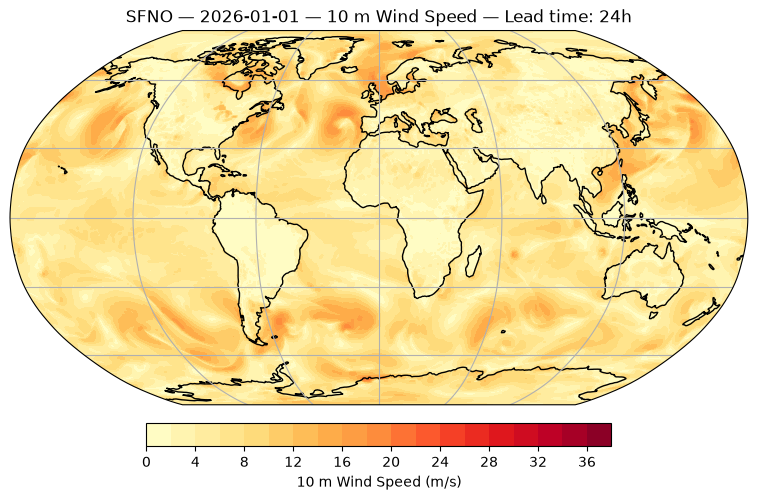

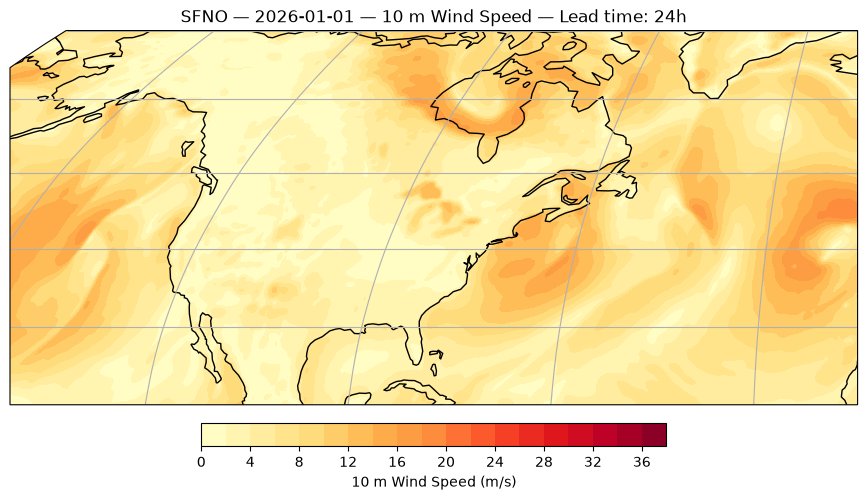

In [6]:
4# 10m wind speed
plot_sfno_10m_wind(sfno_path, step=4)
plot_sfno_10m_wind(sfno_path, step=4, extent=[220, 340, 20, 70])

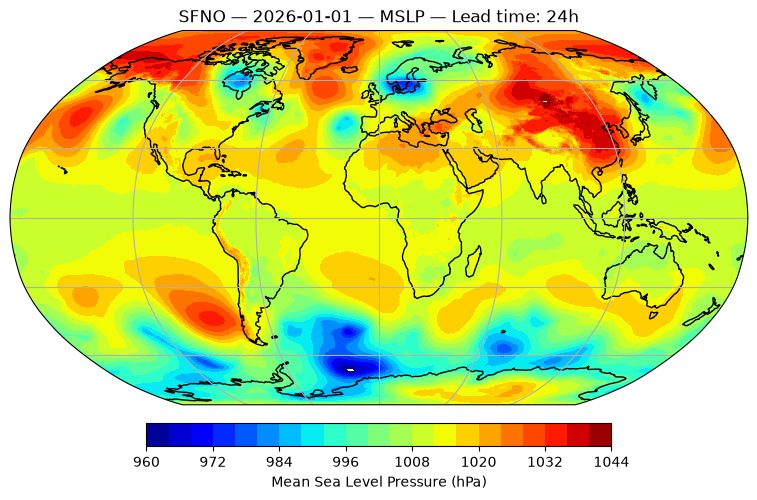

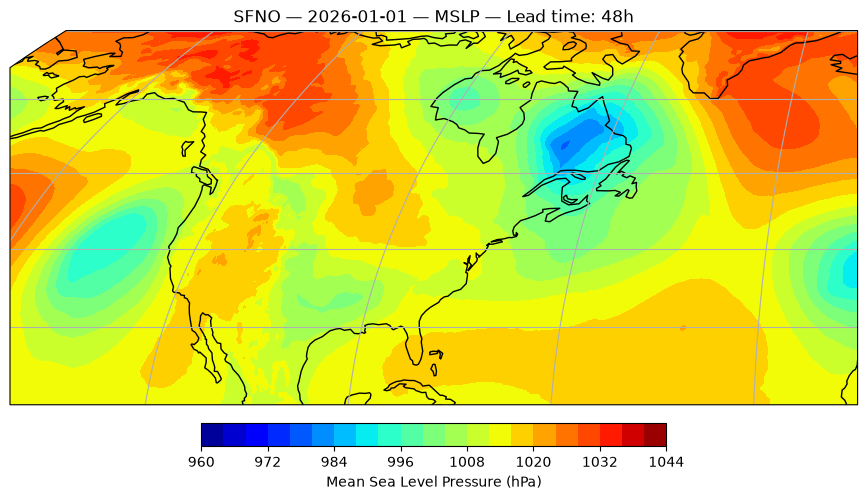

In [7]:
# Mean sea level pressure
plot_sfno_msl(sfno_path, step=4)
plot_sfno_msl(sfno_path, step=8, extent=[220, 340, 20, 70])

## Hurricane Florence Track Comparison

Compare tropical cyclone tracks from SFNO (NVIDIA), FCN (NVIDIA), and ERA5 reanalysis
for Hurricane Florence (September 2018).

In [8]:
FLORENCE_DIR = PROJECT_DIR / "florence_outputs"
FLORENCE_DIR.mkdir(exist_ok=True)

START_TIME = datetime(2018, 9, 13)
NSTEPS = 25
END_TIME = START_TIME + timedelta(hours=6 * NSTEPS)

### Inference helper

In [9]:
def run_tc_inference(prognostic, data_source, tracker, start_time, nsteps, save_path):
    """Run a prognostic model through the TC tracker and save the resulting tracks."""
    prognostic = prognostic.to(DEVICE)
    tracker.reset_path_buffer()

    x, coords = fetch_data(
        source=data_source,
        time=to_time_array([start_time]),
        variable=prognostic.input_coords()["variable"],
        lead_time=prognostic.input_coords()["lead_time"],
        device=DEVICE,
    )
    x, coords = map_coords(x, coords, prognostic.input_coords())

    iterator = prognostic.create_iterator(x, coords)
    for step, (x, coords) in tqdm(enumerate(iterator), total=nsteps + 1):
        x, coords = map_coords(x, coords, tracker.input_coords())
        output, _ = tracker(x, coords)
        output = output[:, 0]
        if step == nsteps:
            break

    tracks = output.cpu()
    torch.save(tracks, str(save_path))
    print(f"Saved: {save_path}")
    return tracks

### 3a — SFNO

In [ ]:
sfno_florence_model = SFNO.load_model(SFNO.load_default_package())
sfno_florence_data = ARCO(cache=True)
tracker = TCTrackerWuDuan()

sfno_florence_tracks = run_tc_inference(
    sfno_florence_model, sfno_florence_data, tracker,
    START_TIME, NSTEPS, FLORENCE_DIR / "sfno_paths.pt",
)

del sfno_florence_model
torch.cuda.empty_cache()

### 3b — ERA5 Reanalysis (ground truth)

In [11]:
era5_data = WB2ERA5(cache=True, verbose=True)
tracker = TCTrackerWuDuan()
tracker.reset_path_buffer()

times = [START_TIME + timedelta(hours=6 * i) for i in range(NSTEPS + 1)]
for step, time in tqdm(enumerate(times), total=len(times)):
    da = era5_data(time, tracker.input_coords()["variable"])
    x, coords = prep_data_array(da, device=DEVICE)
    output, _ = tracker(x, coords)

era5_tracks = output.cpu()
torch.save(era5_tracks, str(FLORENCE_DIR / "era5_paths.pt"))
print("Saved ERA5 tracks")

Fetching WB2 data: 100%|██████████| 5/5 [00:00<00:00, 62.50it/s]

2026-08-08 08:29:00.184 | DEBUG    | earth2studio.data.wb2:fetch_array:201 - Fetching WB2 zarr array for variable: msl at 2018-09-13T00:00:00
2026-08-08 08:29:00.186 | DEBUG    | earth2studio.data.wb2:fetch_array:201 - Fetching WB2 zarr array for variable: u850 at 2018-09-13T00:00:00
2026-08-08 08:29:00.189 | DEBUG    | earth2studio.data.wb2:fetch_array:201 - Fetching WB2 zarr array for variable: v10m at 2018-09-13T00:00:00
2026-08-08 08:29:00.191 | DEBUG    | earth2studio.data.wb2:fetch_array:201 - Fetching WB2 zarr array for variable: u10m at 2018-09-13T00:00:00
2026-08-08 08:29:00.193 | DEBUG    | earth2studio.data.wb2:fetch_array:201 - Fetching WB2 zarr array for variable: v850 at 2018-09-13T00:00:00

Fetching WB2 data: 100%|██████████| 5/5 [00:00<00:00, 64.85it/s]

2026-08-08 08:29:00.408 | DEBUG    | earth2studio.data.wb2:fetch_array:201 - Fetching WB2 zarr array for variable: v850 at 2018-09-13T06:00:00
2026-08-08 08:29:00.410 | DEBUG    | earth2studio.data.wb2:fetch_array:201 - Fetching WB2 zarr array for variable: v10m at 2018-09-13T06:00:00
2026-08-08 08:29:00.412 | DEBUG    | earth2studio.data.wb2:fetch_array:201 - Fetching WB2 zarr array for variable: u10m at 2018-09-13T06:00:00
2026-08-08 08:29:00.414 | DEBUG    | earth2studio.data.wb2:fetch_array:201 - Fetching WB2 zarr array for variable: msl at 2018-09-13T06:00:00
2026-08-08 08:29:00.417 | DEBUG    | earth2studio.data.wb2:fetch_array:201 - Fetching WB2 zarr array for variable: u850 at 2018-09-13T06:00:00

 12%|█▏        | 3/26 [00:01<00:07,  3.03it/s]

...

2026-08-08 08:29:04.795 | DEBUG    | earth2studio.data.wb2:fetch_array:201 - Fetching WB2 zarr array for variable: v10m at 2018-09-18T18:00:00
2026-08-08 08:29:04.797 | DEBUG    | earth2studio.data.wb2:fetch_array:201 - Fetching WB2 zarr array for variable: u10m at 2018-09-18T18:00:00
2026-08-08 08:29:04.799 | DEBUG    | earth2studio.data.wb2:fetch_array:201 - Fetching WB2 zarr array for variable: u850 at 2018-09-18T18:00:00
2026-08-08 08:29:04.801 | DEBUG    | earth2studio.data.wb2:fetch_array:201 - Fetching WB2 zarr array for variable: msl at 2018-09-18T18:00:00
2026-08-08 08:29:04.805 | DEBUG    | earth2studio.data.wb2:fetch_array:201 - Fetching WB2 zarr array for variable: v850 at 2018-09-18T18:00:00

Fetching WB2 data: 100%|██████████| 5/5 [00:00<00:00, 55.90it/s]

2026-08-08 08:29:05.012 | DEBUG    | earth2studio.data.wb2:fetch_array:201 - Fetching WB2 zarr array for variable: v10m at 2018-09-19T00:00:00
2026-08-08 08:29:05.017 | DEBUG    | earth2studio.data.wb2:fetch_array:201 - Fetching WB2 zarr array for variable: u10m at 2018-09-19T00:00:00
2026-08-08 08:29:05.018 | DEBUG    | earth2studio.data.wb2:fetch_array:201 - Fetching WB2 zarr array for variable: msl at 2018-09-19T00:00:00
2026-08-08 08:29:05.020 | DEBUG    | earth2studio.data.wb2:fetch_array:201 - Fetching WB2 zarr array for variable: v850 at 2018-09-19T00:00:00
2026-08-08 08:29:05.023 | DEBUG    | earth2studio.data.wb2:fetch_array:201 - Fetching WB2 zarr array for variable: u850 at 2018-09-19T00:00:00

100%|██████████| 26/26 [00:05<00:00,  4.49it/s]

2026-08-08 08:29:05.232 | DEBUG    | earth2studio.data.wb2:fetch_array:201 - Fetching WB2 zarr array for variable: v10m at 2018-09-19T06:00:00
2026-08-08 08:29:05.234 | DEBUG    | earth2studio.data.wb2:fetch_array:201 - Fetching WB2 zarr array for variable: u10m at 2018-09-19T06:00:00
2026-08-08 08:29:05.236 | DEBUG    | earth2studio.data.wb2:fetch_array:201 - Fetching WB2 zarr array for variable: v850 at 2018-09-19T06:00:00
2026-08-08 08:29:05.238 | DEBUG    | earth2studio.data.wb2:fetch_array:201 - Fetching WB2 zarr array for variable: msl at 2018-09-19T06:00:00
2026-08-08 08:29:05.241 | DEBUG    | earth2studio.data.wb2:fetch_array:201 - Fetching WB2 zarr array for variable: u850 at 2018-09-19T06:00:00
Saved ERA5 tracks

### 3c — FCN

In [12]:
fcn_model = FCN.load_model(FCN.load_default_package())
fcn_data = NCAR_ERA5()
tracker = TCTrackerWuDuan()

fcn_tracks = run_tc_inference(
    fcn_model, fcn_data, tracker,
    START_TIME, NSTEPS, FLORENCE_DIR / "fcn_paths.pt",
)

del fcn_model
torch.cuda.empty_cache()

Fetching NCAR ERA5 data:   0%|          | 0/13 [00:00<?, ?it/s]

2026-08-08 08:29:06.662 | DEBUG    | earth2studio.data.ncar:fetch_array:437 - Fetching NCAR ERA5 variable: 100U in file s3://nsf-ncar-era5/e5.oper.an.sfc/201809/e5.oper.an.sfc.228_246_100u.ll025sc.2018090100_2018093023.nc
2026-08-08 08:29:06.664 | DEBUG    | earth2studio.data.ncar:fetch_array:437 - Fetching NCAR ERA5 variable: 2T in file s3://nsf-ncar-era5/e5.oper.an.sfc/201809/e5.oper.an.sfc.128_167_2t.ll025sc.2018090100_2018093023.nc
2026-08-08 08:29:06.668 | DEBUG    | earth2studio.data.ncar:fetch_array:437 - Fetching NCAR ERA5 variable: SP in file s3://nsf-ncar-era5/e5.oper.an.sfc/201809/e5.oper.an.sfc.128_134_sp.ll025sc.2018090100_2018093023.nc
2026-08-08 08:29:06.671 | DEBUG    | earth2studio.data.ncar:fetch_array:437 - Fetching NCAR ERA5 variable: R in file s3://nsf-ncar-era5/e5.oper.an.pl/201809/e5.oper.an.pl.128_157_r.ll025sc.2018091300_2018091323.nc
2026-08-08 08:29:06.674 | DEBUG    | earth2studio.data.ncar:fetch_array:437 - Fetching NCAR ERA5 variable: TCWV in file s3://nsf

 96%|█████████▌| 25/26 [00:04<00:00,  5.68it/s]

Saved: /home/jovyan/Earth2/florence_outputs/fcn_paths.pt

### 3d — Plot Track Comparison

In [3]:
def add_cities(ax, city_list, offset=(0.22, 0.22)):
    """Annotate cities on a cartopy axis. Each entry: (name, lat, lon[, dx, dy])."""
    text_kw = dict(
        fontsize=8, zorder=11, transform=ccrs.PlateCarree(),
        path_effects=[pe.withStroke(linewidth=2, foreground="white")],
    )
    for item in city_list:
        name, lat, lon = item[0], item[1], item[2]
        dx, dy = (item[3], item[4]) if len(item) == 5 else offset
        ax.plot(lon, lat, "o", color="red", markersize=3, zorder=10, transform=ccrs.PlateCarree())
        ax.text(lon + dx, lat + dy, name, **text_kw)


def plot_hurricane_tracks(models, start_time=None, end_time=None,
                          extent=(-95, -60, 30, 45), cities=None,
                          title="Tropical Cyclone Tracks", save_path=None):
    """Plot one or more TC track sets on a single map."""
    projection = ccrs.Robinson()
    fig, ax = plt.subplots(subplot_kw={"projection": projection}, figsize=(10, 8))

    ax.add_feature(cfeature.OCEAN, facecolor="#cfe8f3")
    ax.add_feature(cfeature.LAND, facecolor="#f2e8d5")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="#555555")
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, alpha=0.5)
    ax.add_feature(cfeature.STATES, linewidth=0.5, alpha=0.5)
    ax.gridlines(draw_labels=True, linewidth=0.6, alpha=0.2)
    ax.set_extent(extent)

    for m in models:
        tracks = m["tracks"]
        if hasattr(tracks, "detach"):
            tracks = tracks.detach().cpu().numpy()

        label_set = False
        for p in range(tracks.shape[1]):
            lats, lons = tracks[0, p, :, 0], tracks[0, p, :, 1]
            mask = ~np.isnan(lats) & ~np.isnan(lons)
            if mask.sum() > 2:
                ax.plot(
                    lons[mask], lats[mask],
                    color=m.get("color"), linewidth=m.get("lw", 2),
                    linestyle=m.get("ls", "--"),
                    label=m["name"] if not label_set else "",
                    transform=ccrs.PlateCarree(), zorder=6,
                )
                label_set = True

    if cities:
        add_cities(ax, cities)

    if start_time and end_time:
        ax.set_title(f"{title}\n{start_time:%Y-%m-%d} to {end_time:%Y-%m-%d}")
    else:
        ax.set_title(title)

    ax.legend(loc="lower right", title="Models")
    if save_path:
        plt.savefig(str(save_path), bbox_inches="tight")
    plt.show()

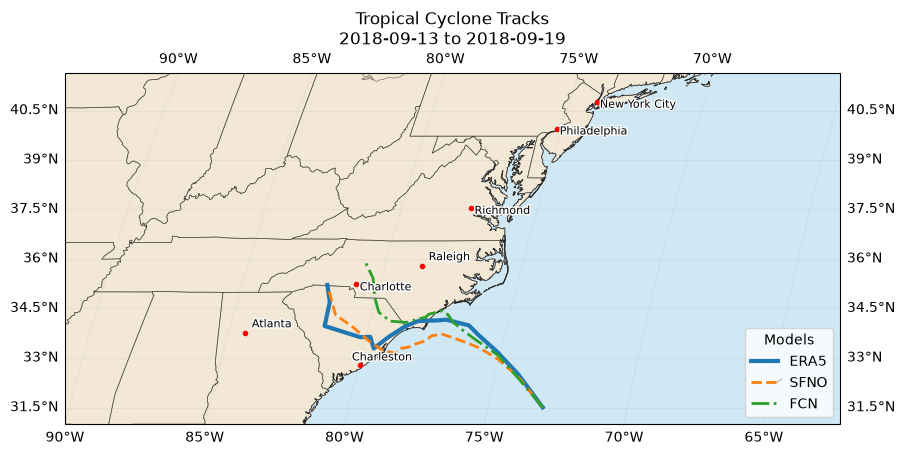

In [19]:
# Load saved tracks (or use variables from cells above)
era5_load = torch.load(FLORENCE_DIR / "era5_paths.pt", map_location="cpu")
sfno_load = torch.load(FLORENCE_DIR / "sfno_paths.pt", map_location="cpu")
fcn_load = torch.load(FLORENCE_DIR / "fcn_paths.pt", map_location="cpu")

cities = [
    ("Charlotte",    35.2271, -80.8431,  0.18, -0.18),
    ("Raleigh",      35.7796, -78.6382,  0.18,  0.18),
    ("Charleston",   32.7765, -79.9311, -0.35,  0.15),
    ("Atlanta",      33.7490, -84.3880,  0.18,  0.18),
    ("Richmond",     37.5407, -77.4360,  0.18, -0.18),
    ("Philadelphia", 39.9526, -75.1652,  0.18, -0.18),
    ("New York City", 40.7685, -73.9822,  0.18, -0.18),
]

models = [
    {"name": "ERA5",  "tracks": era5_load, "color": "#1f77b4", "lw": 3.0, "ls": "-"},
    {"name": "SFNO",  "tracks": sfno_load, "color": "#ff7f0e", "lw": 2.0, "ls": "--"},
    {"name": "FCN",   "tracks": fcn_load,  "color": "#2ca02c", "lw": 2.0, "ls": "-."},
]

plot_hurricane_tracks(
    models,
    start_time=START_TIME, end_time=END_TIME,
    extent=(-90, -65, 31, 41),
    cities=cities,
)


---
## 14-Day Extended Range Forecast: Aurora

Aurora (Microsoft, 2024) runs at 0.25° resolution with 6-hour timesteps.
Here we step it 56 times (14 days) from **January 5, 2025** — the onset of a
major polar vortex disruption — and animate the daily 500 hPa geopotential
height evolution over the Northern Hemisphere.


In [15]:
AURORA_START = "2025-01-05T00:00:00"
AURORA_STEPS = 56       # 14 days × 4 steps/day at 6h
AURORA_SAVE_EVERY = 4   # one frame per day
G = 9.80665             # m s⁻²

aurora_model = Aurora.load_model(Aurora.load_default_package())
aurora_model = aurora_model.to(DEVICE).eval()

gfs_source = GFS()
time_array = to_time_array([AURORA_START])
x, coords = fetch_data(
    source=gfs_source,
    time=time_array,
    variable=aurora_model.input_coords()["variable"],
    lead_time=aurora_model.input_coords()["lead_time"],
    device=DEVICE,
)
x, coords = map_coords(x, coords, aurora_model.input_coords())

z500_frames, frame_labels = [], []

iterator = aurora_model.create_iterator(x, coords)
for step, (x, coords) in tqdm(enumerate(iterator), total=AURORA_STEPS, desc="Aurora 14-day forecast"):
    if (step + 1) % AURORA_SAVE_EVERY == 0:
        var_list = list(coords["variable"])
        z_idx = var_list.index("z500")
        z500_frames.append(x[0, 0, z_idx].cpu().numpy())
        day = (step + 1) // AURORA_SAVE_EVERY
        valid = np.datetime64(AURORA_START) + np.timedelta64(day, "D")
        frame_labels.append(f"Day +{day}  ({str(valid)[:10]})") 
    if step + 1 >= AURORA_STEPS:
        break

print(f"Collected {len(z500_frames)} daily frames.")

del aurora_model
torch.cuda.empty_cache()

2026-08-08 08:29:37.863 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 256987656-722885
2026-08-08 08:29:37.864 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 193696762-1168037
2026-08-08 08:29:37.878 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 256179873-807783
2026-08-08 08:29:37.897 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 394833241-1213447
2026-08-08 08:29:37.916 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 413933367-881891
2026-08-08 08:29:37.933 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GF

Fetching GFS data:   0%|          | 0/69 [00:00<?, ?it/s]

2026-08-08 08:29:38.054 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 208528076-595160
2026-08-08 08:29:38.074 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 154058344-843261
2026-08-08 08:29:38.087 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 306561519-907354
2026-08-08 08:29:38.105 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 213311528-754621
2026-08-08 08:29:38.122 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 172302074-1137734
2026-08-08 08:29:38.140 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS

2026-08-08 08:29:38.274 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 302953413-1258846
2026-08-08 08:29:38.288 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 187239250-910433
2026-08-08 08:29:38.306 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 365864700-951602
2026-08-08 08:29:38.323 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 262490294-964275
2026-08-08 08:29:38.339 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 191886636-752406
2026-08-08 08:29:38.354 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS

Fetching GFS data:   0%|          | 0/69 [00:00<?, ?it/s]

...

2026-08-08 08:29:40.052 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 357004103-933233
2026-08-08 08:29:40.067 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 416837147-960688
2026-08-08 08:29:40.072 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 262748432-558334
2026-08-08 08:29:40.099 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 196838387-986419
2026-08-08 08:29:40.104 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 396603345-961143
2026-08-08 08:29:40.127 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS 

Fetching GFS data: 100%|██████████| 69/69 [00:01<00:00, 56.12it/s]

2026-08-08 08:29:40.353 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 277447616-841782
2026-08-08 08:29:40.355 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 417797835-939320
2026-08-08 08:29:40.370 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 241464327-591397
2026-08-08 08:29:40.385 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 186190584-969152
2026-08-08 08:29:40.386 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 363750587-940418

Aurora 14-day forecast:  48%|████▊     | 27/56 [02:30<02:41,  5.56s/it]

KeyboardInterrupt: 

Saved: /home/jovyan/Earth2/aurora_outputs/aurora_z500_nh_14day.gif

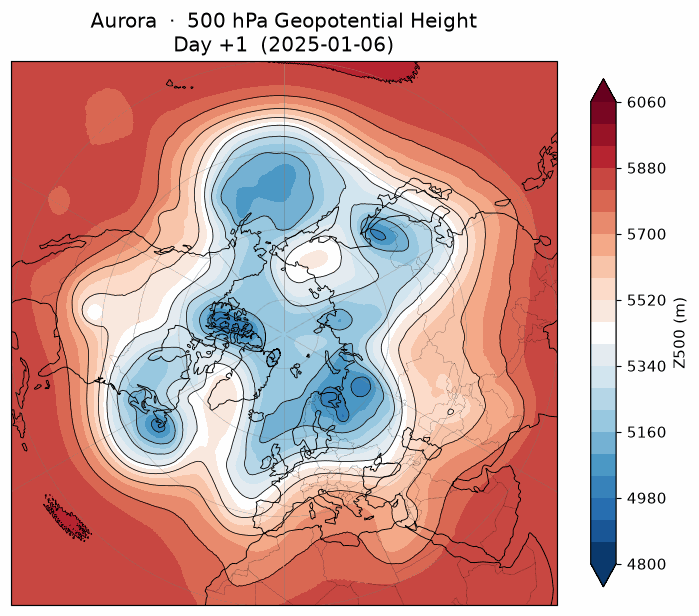

In [20]:
lats = np.asarray(coords["lat"])
lons = np.asarray(coords["lon"])

proj = ccrs.NorthPolarStereo()
frames_png = []

for z500, label in zip(z500_frames, frame_labels):
    z_height = z500 / G  # geopotential (m²/s²) → geopotential height (m)

    fig, ax = plt.subplots(1, 1, figsize=(8, 8), subplot_kw={"projection": proj})
    ax.set_extent([-180, 180, 20, 90], ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
    ax.gridlines(draw_labels=False, linewidth=0.4, color="gray", alpha=0.5)

    levels = np.arange(4800, 6100, 60)
    cf = ax.contourf(
        lons, lats, z_height, levels=levels,
        cmap="RdBu_r", transform=ccrs.PlateCarree(), extend="both",
    )
    ax.contour(
        lons, lats, z_height, levels=np.arange(4800, 6100, 120),
        colors="black", linewidths=0.5, transform=ccrs.PlateCarree(),
    )

    plt.colorbar(cf, ax=ax, label="Z500 (m)", shrink=0.75, pad=0.05)
    ax.set_title(f"Aurora  ·  500 hPa Geopotential Height\n{label}", fontsize=13)

    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    buf.seek(0)
    frames_png.append(imageio.v2.imread(buf))
    plt.close(fig)

gif_path = PROJECT_DIR / "aurora_outputs/aurora_z500_nh_14day.gif"
imageio.mimsave(str(gif_path), frames_png, fps=2, loop=0)
print(f"Saved: {gif_path}")
IPImage(str(gif_path))